連続時間信号 $x(t) = \cos(100 \pi t)$ をサンプリング周波数 $F_s = 1000$ Hz で標本化した離散時間信号 $x[n]$ に対し，
$N = 1024, 256, 64, 16$ 点 DFT を計算し，横軸を周波数$F$ [Hz] としてそれぞれの振幅スペクトルをプロットしなさい．
また，DFTの点数がスペクトルの見え方にどのような影響を与えるか考察しなさい．

$$
x(t)=\cos(100\pi t)=\cos(2\pi \cdot 50t)
$$

なので，信号周波数は

$$
F = 50\ \mathrm{Hz}
$$

周波数分解能は

$$
\Delta F = \frac{F_s}{N}
$$

| $N$ | $\Delta F$ | $50\ \mathrm{Hz}$ に最も近いビン |
|---:|---:|---:|
| 1024 | $0.9765625\ \mathrm{Hz}$ | $49.8046875\ \mathrm{Hz}$ |
| 256 | $3.90625\ \mathrm{Hz}$ | $50.78125\ \mathrm{Hz}$ |
| 64 | $15.625\ \mathrm{Hz}$ | $46.875\ \mathrm{Hz}$ |
| 16 | $62.5\ \mathrm{Hz}$ | $62.5\ \mathrm{Hz}$ |

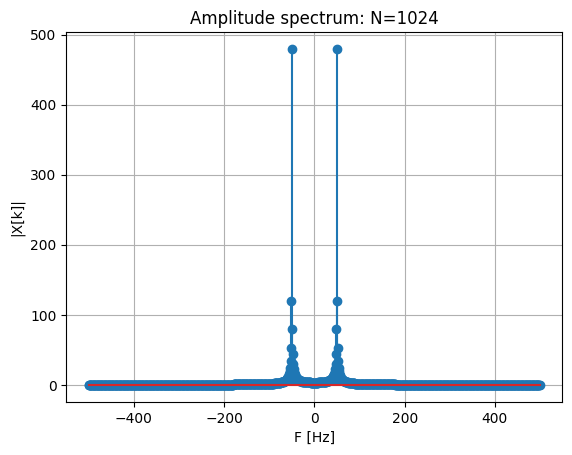

N = 1024
ΔF = 0.9765625
peak frequency = 49.8046875
peak amplitude = 479.5312377408165


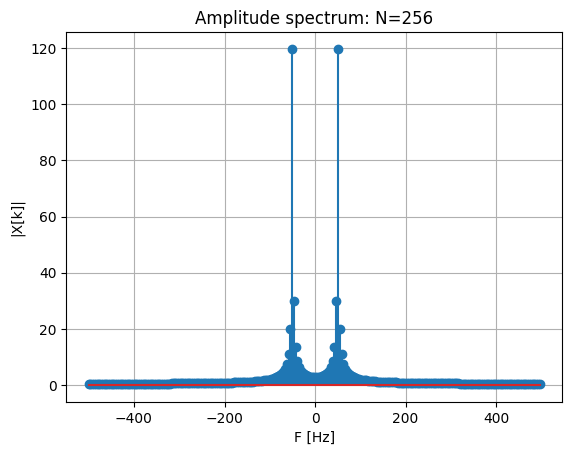

N = 256
ΔF = 3.90625
peak frequency = 50.78125
peak amplitude = 119.74646897250396


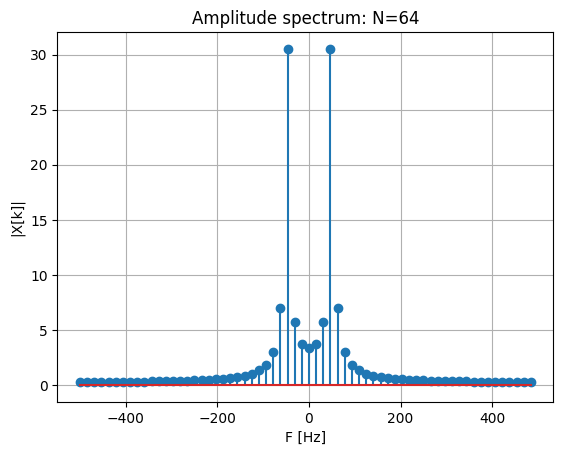

N = 64
ΔF = 15.625
peak frequency = 46.875
peak amplitude = 30.52291456217738


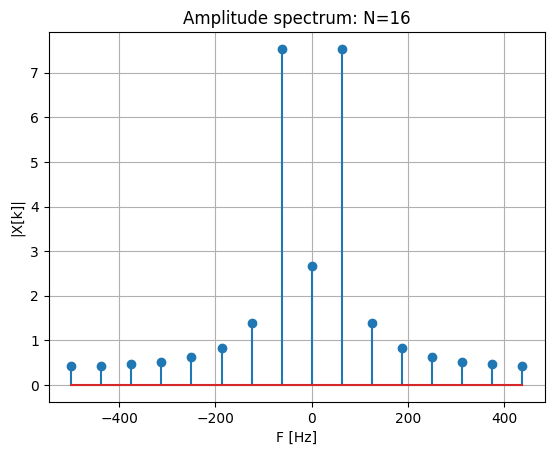

N = 16
ΔF = 62.5
peak frequency = 62.5
peak amplitude = 7.533841396493901


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000
Ns = [1024, 256, 64, 16]

for N in Ns:
    n = np.arange(N)
    t = n / Fs
    x = np.cos(100 * np.pi * t)

    X = np.fft.fft(x)
    F = np.fft.fftfreq(N, d=1/Fs)

    plt.figure()
    plt.stem(F, np.abs(X))
    plt.xlabel("F [Hz]")
    plt.ylabel("|X[k]|")
    plt.title(f"Amplitude spectrum: N={N}")
    plt.grid()
    plt.show()

    positive = F >= 0
    peak = np.argmax(np.abs(X[positive]))
    freq_positive = F[positive]
    amp_positive = np.abs(X[positive])

    print("N =", N)
    print("ΔF =", Fs / N)
    print("peak frequency =", freq_positive[peak])
    print("peak amplitude =", amp_positive[peak])

- $N$ が大きいほど $\Delta F$ が小さくなり，$50\ \mathrm{Hz}$ 付近を細かく観測可能
- $N$ が小さいほど周波数分解能が低くなり，ピーク位置が粗くなる
- $50\ \mathrm{Hz}$ が DFT のビンにぴったり一致しない場合，スペクトル漏れが発生
- $N=16$ では $\Delta F=62.5\ \mathrm{Hz}$ と粗いため，$50\ \mathrm{Hz}$ の信号を正確に表現しにくい